In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets , transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
train_dir = '/kaggle/input/datasets/msambare/fer2013/train/'
test_dir = '/kaggle/input/datasets/msambare/fer2013/test/'

In [3]:
row , col = 48 , 48 #(image size are of pixels 48 by 48)
classes = 7 #no of emotions

def count_expressions(path , set_name):
    """
    this function count total num of emotion in folder
    """
    count_dict = {}
    #os.listdir() -- return the list of sub_folder
    for expression in os.listdir(path):
        dir_path = os.path.join(path , expression)
        if os.path.isdir(dir_path):
            #len(os.listdir()) -- give the total count of files in that particular sub_folder(emotion)
            count_dict[expression] = len(os.listdir(dir_path))

    df = pd.DataFrame(count_dict , index = [set_name])
    return df

train_count = count_expressions(train_dir , 'train')
test_count = count_expressions(test_dir , 'test')

In [4]:
print("--------------Training Set Distributiom -------")
print(train_count)
print("\n---------Test Data Distribution--------------")
print(test_count)

--------------Training Set Distributiom -------
       surprise  fear  angry  neutral   sad  disgust  happy
train      3171  4097   3995     4965  4830      436   7215

---------Test Data Distribution--------------
      surprise  fear  angry  neutral   sad  disgust  happy
test       831  1024    958     1233  1247      111   1774


In [5]:
print(train_count.shape)
train_count.info()

(1, 7)
<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, train to train
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   surprise  1 non-null      int64
 1   fear      1 non-null      int64
 2   angry     1 non-null      int64
 3   neutral   1 non-null      int64
 4   sad       1 non-null      int64
 5   disgust   1 non-null      int64
 6   happy     1 non-null      int64
dtypes: int64(7)
memory usage: 64.0+ bytes


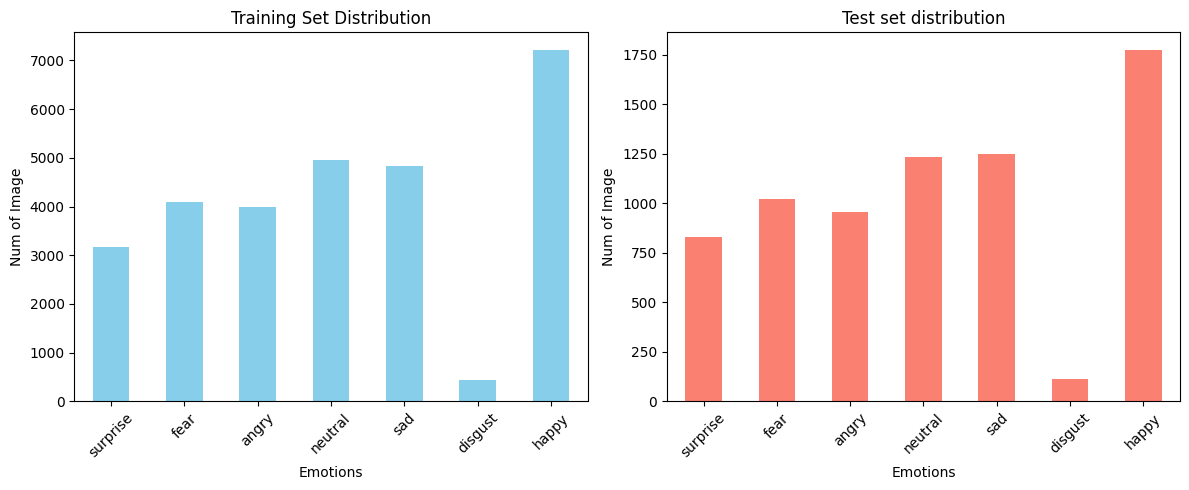

In [6]:
plt.figure(figsize =(12 , 5))
plt.subplot(1 , 2 , 1)
train_count.transpose().plot(kind = 'bar', ax =plt.gca() , color = 'skyblue' ,legend = False)
plt.title('Training Set Distribution')
plt.ylabel('Num of Image')
plt.xlabel("Emotions")
plt.xticks(rotation = 45)

plt.subplot(1 , 2 , 2 )
test_count.transpose().plot(kind='bar', ax=plt.gca(), color='salmon', legend=False)
plt.title('Test set distribution')
plt.xlabel('Emotions')
plt.ylabel('Num of Image')
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

In [7]:
#Transformation for Training Set ( Data Augmentations)
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels =1),  #provide channel of image
    transforms.RandomHorizontalFlip(p=0.5),  #flip the image horizontally with 50% probability
    transforms.RandomRotation(15),    #rotation randomly image from -15 degree to +15 degree
    transforms.ToTensor(),
])
#we should not use Flip and rotation on test data , only scale the pixel
test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels =1),
    transforms.ToTensor(),
])
#load the data by using Image folder
train_dataset = datasets.ImageFolder(root = train_dir , transform =train_transform)
test_dataset = datasets.ImageFolder(root = test_dir , transform = test_transform)

#Create Dataloader (for batch and suffling)
#use suffle = true on only training Data for epoch , so order of data will be change in each epochs and model will not overfitt
train_loader = DataLoader(train_dataset , batch_size = 64 , shuffle = True, num_workers = 2, pin_memory = True)
test_loader = DataLoader(test_dataset , batch_size = 64 , shuffle = False, num_workers =2 , pin_memory = True)

print(f"Total training image found : {len(train_dataset)} belongs to {len(train_dataset.classes)} classes.")
print(f"Total test image found : {len(test_dataset)} belongs to {len(test_dataset.classes)} classes.")
print("\nClass Indices (इमोशन और उनके अलॉटेड नंबर्स):", train_dataset.class_to_idx)

Total training image found : 28709 belongs to 7 classes.
Total test image found : 7178 belongs to 7 classes.

Class Indices (इमोशन और उनके अलॉटेड नंबर्स): {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [8]:
class FERNet(nn.Module):
    def __init__(self , num_classes = 7):
        super(FERNet , self).__init__()
        #input change = 1 because of greyscale image . If image were RCB then channel = 3
        #keras = Conv2D(32 , kernel_size =(3 , 3) , padding = 'same' , activation ='relu' , input_shape = (48 , 48 ,1))
        self.conv1 = nn.Conv2d(in_channels = 1 , out_channels = 32 , kernel_size = 3 , padding = 1)

        #keras = Conv2D(64 , kernel_size = (3 ,3) , padding = 'same' , activation = 'relu', )
        self.conv2 = nn.Conv2d(in_channels = 32 , out_channels =  64 , kernel_size = 3 , padding =1  )
        self.bn1 = nn.BatchNorm2d(64)
        #keras : MaxPooling(2,2) --> image of size ( 48 X 48) - decrease to the size of ( 24 X 24)
        self.pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        #keras : Dropout (0.25%) = 25% neurons off randomly to prevent models from overfitting
        self.dropout1 = nn.Dropout(0.25)


        #--------------------------------------------------
        #Convolutional Block 2
        #--------------------------------------------------
        #keras : Conv2D(128 , kernel_size = (3, 3) , padding = 'same' , activation = 'relu' , kernel_regularizer = regularizers.l2(0.01))
        #use l2 regularity (weight decay) in optimizer not in the layer 
        self.conv3 = nn.Conv2d(in_channels = 64 , out_channels = 128 , kernel_size= 3 , padding =1)
        
        #keras = Conv2D(256 , kernel_size = (3 ,3) , activation ='relu')
        #in keras i not use padding here , so padding will be use as default  padding = 0 (valid) - due to this size of image will be decrease from 24 X 24 to  (22 X 22)
        self.conv4 = nn.Conv2d(in_channels = 128 , out_channels = 256 , kernel_size = 3 , padding = 0)
        self.bn2 = nn.BatchNorm2d(256)
        #keras : MaxPooling2D(pool_size =(2 ,2) , stride = (2 ,2)) --> image size will be 11 X 11  from 22 X 22
        self.pool2 = nn.MaxPool2d(kernel_size =2 , stride = 2)
        self.dropout2 = nn.Dropout(0.25)
        #--------------------------------------------------------
        #Fully Connect DEnSe Layers
        #--------------------------------------------------------
        #keras : Flatten() --> change 2D feature in 1D single Dimention
        #after MaxPool2 , we have now 257 channel and size of image is 11 x 11 
        #total features = 256 X 11 X 11= 30,976 features
        self.fc1 = nn.Linear(256 * 11 * 11,1024)
        self.dropout3 = nn.Dropout(0.5)
        #-------------------------------------------------
        #Final output layers  for all 7 classes 
        #-------------------------------------------------
        #not use softmax funtion in pytorch here beacuse loss function will automatically handle it
        self.fc2 = nn.Linear(1024 , num_classes)
        
    def forward(self ,x ):
        """
        this function decide how the data layers will pass forward
        """
        #Block 1
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.bn1(x)
        x = self.pool1(x)
        x = self.dropout1(x)
        
        #Block 2
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.bn2(x)
        x = self.pool2(x)
        x = self.dropout2(x)
        #Flatten ( Batch size = 256  , 11 , 11 )  -> (Batch_Size , 30976)
        x = x.view(x.size(0),-1)
        #Dense Layers
        x = F.relu(self.fc1(x))
        x = self.dropout3(x)
        x = self.fc2(x)
        
        return x
model = FERNet(num_classes = classes).to(device)
print(model)

FERNet(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1))
  (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=30976, out_features=1024, bias=True)
  (dropout3): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=1024, out_features=7, bias=True)
)


In [9]:
#Loss Function 
#Tips : nn.CrossEntropyLoss of Pytorch apply softmax internally.
#Thats why we not use Softmax in the end of model. This 'Categorical Crossentropy' is part of pytorch.
criterion = nn.CrossEntropyLoss()

#2. Optimizer Setup
#keras code notes : lr=0.0001 , decay=1e-6
#pytorch notes : 'decay of keras' is know as 'weight_decay' there and there used in l2 regression for stop overfitting
optimizer = optim.Adam(model.parameters(), lr=0.0003 , weight_decay = 1e-6)

print("Loss Function and Optimizer initialized successfully!")

Loss Function and Optimizer initialized successfully!


In [10]:
#Cell 7
#====================================================

epochs = 65

train_losses , test_losses = [] , []
train_accuracies , test_accuracies = [] , []

print('Training Started .................')

for epoch in range(epochs):
    #------------------------------------------------------------
    #Training Phase 
    #------------------------------------------------------------
    model.train() #use for to take model in training mode , here dropout and batchnorm will active
    running_loss =0.0
    correct =0
    total =0
    for images , labels in train_loader:
        #send data in gpus for training 
        images , labels = images.to(device) , labels.to(device)
        #a clean the history of previous batch to prent from addition of loss
        optimizer.zero_grad()
        #b forward pass - take prediction from model
        outputs = model(images)
        loss = criterion(outputs , labels)
        #c Backward pass - on the basis of error / loss - calculate gradients 
        loss.backward()
        #d update the weights (optimizer step)
        optimizer.step()
        
        #calculate statstics
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = 100. * correct / total

    #==============================================================
    #2.Validation PhAsE
    #==============================================================
    model.eval()  #take model in evaluation mode ( This stops dropout and keeps BatchNorm stable.)
    running_test_loss =0.0
    test_correct =0
    test_total =0
    #Note = Not need of gradient calculation at the time of validation, this help in save memory
    with torch.no_grad():
        for images , labels in test_loader:
            images , labels = images.to(device) , labels.to(device)
            outputs = model(images)
            loss = criterion(outputs , labels)
            running_test_loss += loss.item() * images.size(0)
            _,predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()
        epoch_test_loss = running_test_loss / len(test_loader.dataset)
        epoch_test_acc = 100. * test_correct/test_total
        train_losses.append(epoch_train_loss)
        test_losses.append(epoch_test_loss)
        train_accuracies.append(epoch_train_acc)
        test_accuracies.append(epoch_test_acc)
        print(f"Epoch [{epoch+1}/{epochs}] ->"
             f"Train loss : {epoch_train_loss:.4f}, train Acc : {epoch_train_acc:.2f}% | "
            f"Test loss : {epoch_test_loss:.4f} , test acc : {epoch_test_acc:.2f}%")

print("training Completed")
            
    
        

Training Started .................
Epoch [1/65] ->Train loss : 1.7750, train Acc : 33.99% | Test loss : 1.4539 , test acc : 43.97%
Epoch [2/65] ->Train loss : 1.4789, train Acc : 42.71% | Test loss : 1.3166 , test acc : 49.44%
Epoch [3/65] ->Train loss : 1.3784, train Acc : 46.60% | Test loss : 1.3128 , test acc : 50.32%
Epoch [4/65] ->Train loss : 1.3179, train Acc : 49.39% | Test loss : 1.2038 , test acc : 53.91%
Epoch [5/65] ->Train loss : 1.2588, train Acc : 52.31% | Test loss : 1.1883 , test acc : 54.99%
Epoch [6/65] ->Train loss : 1.2226, train Acc : 53.23% | Test loss : 1.1684 , test acc : 56.59%
Epoch [7/65] ->Train loss : 1.1815, train Acc : 55.31% | Test loss : 1.1285 , test acc : 57.26%
Epoch [8/65] ->Train loss : 1.1402, train Acc : 56.99% | Test loss : 1.1243 , test acc : 56.98%
Epoch [9/65] ->Train loss : 1.1156, train Acc : 57.98% | Test loss : 1.1015 , test acc : 58.80%
Epoch [10/65] ->Train loss : 1.0770, train Acc : 59.64% | Test loss : 1.0741 , test acc : 60.11%
Epoc

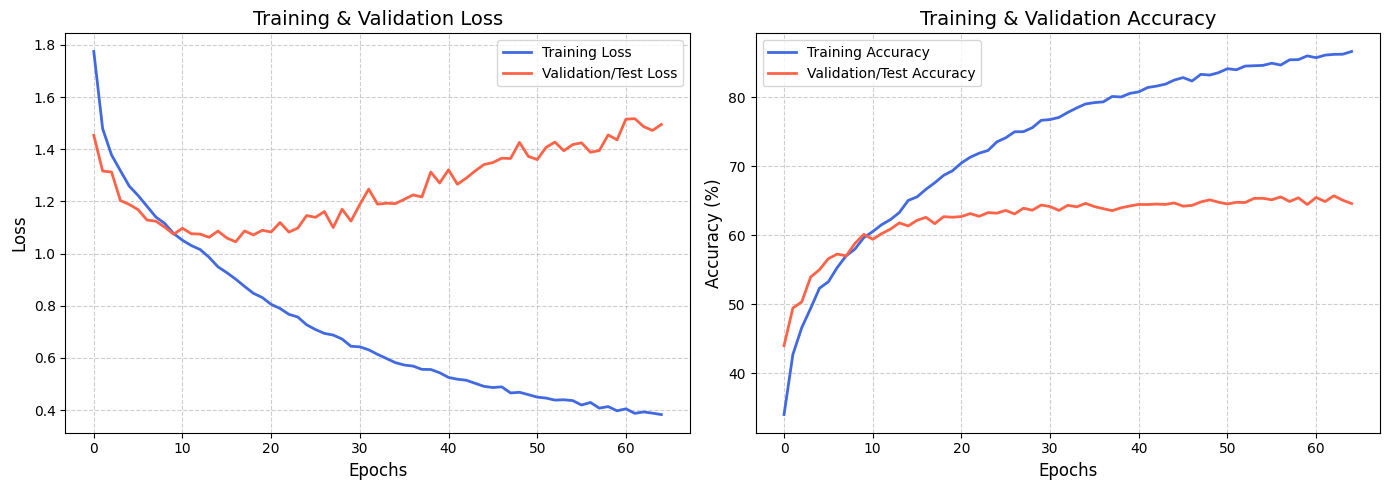

In [11]:
# ==========================================
# CELL 8: PLOTTING LOSS & ACCURACY GRAPH
# ==========================================

plt.figure(figsize=(14, 5))

# 1. Loss graph
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='royalblue', linewidth=2)
plt.plot(test_losses, label='Validation/Test Loss', color='tomato', linewidth=2)
plt.title('Training & Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Accuracy graph
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy', color='royalblue', linewidth=2)
plt.plot(test_accuracies, label='Validation/Test Accuracy', color='tomato', linewidth=2)
plt.title('Training & Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [12]:
torch.save(model.state_dict(), 'fer_net_baseline.pth')

print("Baseline Model weights saved successfully as 'fer_net_baseline.pth'! 🎉")

Baseline Model weights saved successfully as 'fer_net_baseline.pth'! 🎉


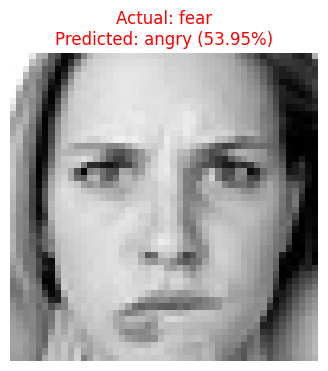

In [13]:
# ==========================================
# CELL 10: TESTING THE MODEL ON A RANDOM IMAGE
# ==========================================

import random

model.eval()

random_idx = random.randint(0, len(test_dataset) - 1)

image_tensor, actual_label_idx = test_dataset[random_idx]
actual_label = test_dataset.classes[actual_label_idx]

input_tensor = image_tensor.unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(input_tensor)
    probabilities = F.softmax(outputs, dim=1)
    confidence, predicted_label_idx = torch.max(probabilities, 1)

predicted_label = test_dataset.classes[predicted_label_idx.item()]
confidence_score = confidence.item() * 100

plt.figure(figsize=(4, 4))
plt.imshow(image_tensor.squeeze(), cmap='gray')

title_color = 'green' if predicted_label == actual_label else 'red'

plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label} ({confidence_score:.2f}%)", 
          color=title_color, fontsize=12)
plt.axis('off')
plt.show()